# Proyecto VPC: Ataque Adversarial Real Contra YOLOv8-OBB

Este notebook reemplaza la prueba de texturas fijas. La textura se optimiza por gradiente contra el forward diferenciable de YOLOv8-OBB.

Reglas del experimento:

- La textura es un tensor optimizable `theta` con `requires_grad=True`.
- YOLO permanece congelado; no se entrenan sus pesos.
- La composicion de textura usa torch/kornia; no PIL en el camino de gradiente.
- La textura se aplica solo sobre la huella del objeto.
- Primero se valida un objeto; despues se prueba textura universal.

## 1. Entorno, Drive E Imports

In [ ]:
!pip install -q ultralytics kornia

from google.colab import drive
drive.mount('/content/drive')

import json
import random
from pathlib import Path

import kornia.augmentation as K
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import ultralytics
from PIL import Image
from ultralytics import YOLO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

PROJECT_ROOT = Path('/content/drive/MyDrive/Proyecto-VPC')
PREDICTIONS_JSON = PROJECT_ROOT / 'results/digital/baseline_yolo_obb/predictions.json'
DOTA_ROOT = PROJECT_ROOT / 'data/raw/dota_v1'
OUTPUT_DIR = PROJECT_ROOT / 'results/digital/adversarial_gradient'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 1024
WORK_IMAGE_PATH = Path('/content/attack_input_1024.jpg')
TARGET_NAMES = {'small vehicle', 'large vehicle'}

print('torch', torch.__version__, '| cuda', torch.cuda.is_available(), '| device', DEVICE)
print('ultralytics', ultralytics.__version__)
print('predictions:', PREDICTIONS_JSON, PREDICTIONS_JSON.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
torch 2.10.0+cu128 | cuda True | device cuda
ultralytics 8.4.54
predictions: /content/drive/MyDrive/Proyecto-VPC/results/digital/baseline_yolo_obb/predictions.json True


## 2. Cargar YOLOv8-OBB Congelado

In [ ]:
yolo = YOLO('yolov8n-obb.pt')
model = yolo.model.to(DEVICE).eval()

for p in model.parameters():
    p.requires_grad_(False)

CLASS_NAMES = yolo.names
TARGET_IDS = [i for i, name in CLASS_NAMES.items() if name in TARGET_NAMES]

print('Clases:', CLASS_NAMES)
print('Target names:', TARGET_NAMES)
print('Target ids:', TARGET_IDS)
assert TARGET_IDS, 'No encontre IDs para las clases objetivo.'

Clases: {0: 'plane', 1: 'ship', 2: 'storage tank', 3: 'baseball diamond', 4: 'tennis court', 5: 'basketball court', 6: 'ground track field', 7: 'harbor', 8: 'bridge', 9: 'large vehicle', 10: 'small vehicle', 11: 'helicopter', 12: 'roundabout', 13: 'soccer ball field', 14: 'swimming pool'}
Target names: {'small vehicle', 'large vehicle'}
Target ids: [9, 10]


## 3. Forward Diferenciable Y Split De Predicciones

Validamos que el tensor crudo tenga layout `[B, 4+nc+1, A]`: 4 caja, `nc` clases y 1 angulo.

In [ ]:
def _find_prediction_tensor(out, nc):
    expected = 4 + nc + 1
    if torch.is_tensor(out):
        if out.ndim == 3 and (out.shape[1] == expected or out.shape[2] == expected):
            return out
        raise TypeError(f'Tensor inesperado: shape={tuple(out.shape)}, expected={expected}')

    if isinstance(out, (tuple, list)):
        for item in out:
            try:
                return _find_prediction_tensor(item, nc)
            except TypeError:
                continue

    raise TypeError(f'No pude encontrar tensor de predicciones en {type(out)}')


def yolo_forward_raw(image_bchw):
    out = model(image_bchw)
    raw = _find_prediction_tensor(out, len(CLASS_NAMES))
    expected = 4 + len(CLASS_NAMES) + 1
    if raw.shape[1] != expected and raw.shape[2] == expected:
        raw = raw.transpose(1, 2).contiguous()
    return raw


def split_predictions(raw):
    nc = len(CLASS_NAMES)
    expected = 4 + nc + 1
    if raw.ndim != 3:
        raise ValueError(f'raw debe ser 3D, recibido {tuple(raw.shape)}')
    if raw.shape[1] != expected and raw.shape[2] == expected:
        raw = raw.transpose(1, 2).contiguous()
    if raw.shape[1] != expected:
        raise ValueError(f'Layout no soportado: {tuple(raw.shape)}, expected C={expected}')

    boxes = raw[:, 0:4, :]
    cls_raw = raw[:, 4:4 + nc, :]
    angle = raw[:, 4 + nc:4 + nc + 1, :]

    # Ultralytics suele devolver confianzas post-sigmoide; si son logits, corregimos.
    cls = cls_raw.sigmoid() if (cls_raw.detach().min() < 0 or cls_raw.detach().max() > 1) else cls_raw
    return boxes, cls, angle


dummy = torch.rand(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.no_grad():
    raw = yolo_forward_raw(dummy)
boxes, cls, angle = split_predictions(raw)

print('raw.shape:', tuple(raw.shape))
print('boxes:', tuple(boxes.shape), 'cls:', tuple(cls.shape), 'angle:', tuple(angle.shape))
print('cls range:', float(cls.min()), float(cls.max()))
assert raw.shape[1] == 4 + len(CLASS_NAMES) + 1, 'raw no esta en layout [B,4+nc+1,A]'
assert cls.min() >= 0 and cls.max() <= 1, 'cls debe estar post-sigmoide'

raw.shape: (1, 20, 21504)
boxes: (1, 4, 21504) cls: (1, 15, 21504) angle: (1, 1, 21504)
cls range: 7.66521690565014e-09 0.006550739519298077


## 4. Elegir Imagen DOTA Y Objeto Objetivo

Usa `predictions.json` si existe. Si no, busca imagenes dentro de `data/raw/dota_v1`. YOLO elige el vehiculo objetivo en una copia 1024x1024 para que la escala del bbox coincida con el forward diferenciable.

Imagen base: /content/drive/MyDrive/Proyecto-VPC/data/raw/dota_v1/images/images/P0002.png
Imagen de trabajo: /content/attack_input_1024.jpg
Objeto objetivo: clase=large vehicle bbox=(451.6,332.1,488.2,386.5) area=1998.3


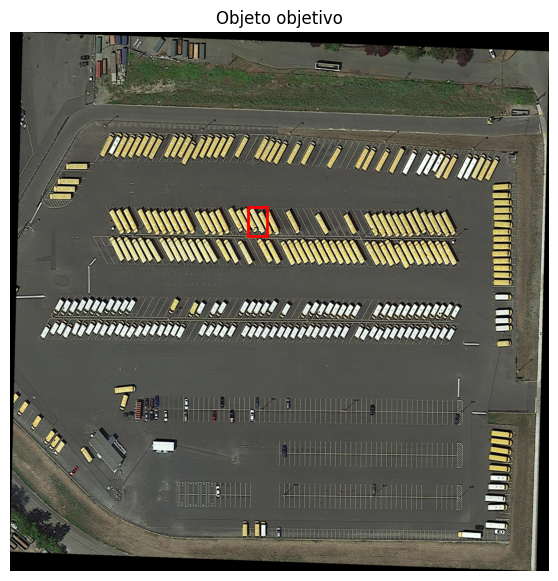

In [ ]:
def choose_dota_image():
    if PREDICTIONS_JSON.exists():
        payload = json.loads(PREDICTIONS_JSON.read_text(encoding='utf-8'))
        for record in payload.get('records', []):
            has_target = any(det.get('class_name') in TARGET_NAMES for det in record.get('detections', []))
            path = Path(record.get('image_path', ''))
            if has_target and path.exists():
                return path

    candidates = []
    for ext in ('*.png', '*.jpg', '*.jpeg', '*.tif', '*.tiff'):
        candidates.extend(DOTA_ROOT.rglob(ext))
    assert candidates, f'No encontre imagenes en {DOTA_ROOT}'
    return sorted(candidates)[0]


def prepare_work_image(path, size=IMG_SIZE):
    img = Image.open(path).convert('RGB').resize((size, size))
    img.save(WORK_IMAGE_PATH, quality=95)
    arr = np.array(img)
    tensor = torch.from_numpy(arr).float().permute(2, 0, 1) / 255.0
    return tensor.unsqueeze(0)


IMAGE_PATH = choose_dota_image()
image = prepare_work_image(IMAGE_PATH).to(DEVICE)

det = yolo.predict(str(WORK_IMAGE_PATH), imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
assert det.obb is not None and len(det.obb) > 0, 'YOLO no detecto nada; usa otra imagen'

xyxy = det.obb.xyxy.detach().cpu().numpy()
cls_ids = det.obb.cls.detach().cpu().numpy().astype(int)
areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
order = np.argsort(-areas)
pick = next((i for i in order if cls_ids[i] in TARGET_IDS), None)
assert pick is not None, 'YOLO no encontro vehiculos objetivo en esta imagen'

X1, Y1, X2, Y2 = xyxy[pick]
box = (float(X1), float(Y1), float(X2), float(Y2))

print('Imagen base:', IMAGE_PATH)
print('Imagen de trabajo:', WORK_IMAGE_PATH)
print(f'Objeto objetivo: clase={CLASS_NAMES[cls_ids[pick]]} bbox=({X1:.1f},{Y1:.1f},{X2:.1f},{Y2:.1f}) area={areas[pick]:.1f}')

plt.figure(figsize=(7, 7))
plt.imshow(image[0].permute(1, 2, 0).detach().cpu())
plt.gca().add_patch(plt.Rectangle((X1, Y1), X2-X1, Y2-Y1, fill=False, ec='red', lw=2))
plt.title('Objeto objetivo')
plt.axis('off')
plt.show()

## 5. Textura Optimizable Y Composicion Diferenciable

In [ ]:
PATCH_H, PATCH_W = 128, 128
theta = None
optimizer = None


def reset_texture(init_scale=0.5, lr=0.1):
    global theta, optimizer
    theta = torch.randn(3, PATCH_H, PATCH_W, device=DEVICE) * init_scale
    theta.requires_grad_(True)
    optimizer = torch.optim.Adam([theta], lr=lr)
    return theta


def get_texture():
    return torch.sigmoid(theta)


def clamp_box(box, width=IMG_SIZE, height=IMG_SIZE):
    x1, y1, x2, y2 = [int(round(v)) for v in box]
    x1 = max(0, min(width - 1, x1))
    y1 = max(0, min(height - 1, y1))
    x2 = max(x1 + 1, min(width, x2))
    y2 = max(y1 + 1, min(height, y2))
    return x1, y1, x2, y2


eot_geom = K.RandomAffine(degrees=15.0, scale=(0.85, 1.15), p=1.0)
eot_color = K.ColorJitter(brightness=0.25, contrast=0.25, p=1.0)


def apply_eot(patch):
    out = eot_geom(patch)
    out = eot_color(out)
    out = out + torch.randn_like(out) * 0.01
    return out.clamp(0.0, 1.0)


def place_texture(image_bchw, texture_chw, box, eot=True):
    b, c, h, w = image_bchw.shape
    x1, y1, x2, y2 = clamp_box(box, w, h)
    bw, bh = x2 - x1, y2 - y1

    patch = texture_chw.unsqueeze(0)
    if eot:
        patch = apply_eot(patch)
    patch = F.interpolate(patch, size=(bh, bw), mode='bilinear', align_corners=False)

    canvas = torch.zeros_like(image_bchw)
    mask = torch.zeros(1, 1, h, w, device=image_bchw.device, dtype=image_bchw.dtype)
    canvas[:, :, y1:y2, x1:x2] = patch
    mask[:, :, y1:y2, x1:x2] = 1.0
    return image_bchw * (1.0 - mask) + canvas * mask


reset_texture()
print('theta:', tuple(theta.shape), '| parametros:', theta.numel())

theta: (3, 128, 128) | parametros: 49152


## 6. Loss Correcto: Max Confianza Dentro De Zona Del Objeto

Usamos `max_inside` porque el promedio diluye la senal. El loss inicial deberia acercarse a la confianza de YOLO `predict` dentro del objeto.

In [ ]:
def detection_loss(raw, box, return_debug=False, pad_scale=0.5):
    boxes, cls, _ = split_predictions(raw)
    cx, cy = boxes[:, 0, :], boxes[:, 1, :]
    x1, y1, x2, y2 = box

    pad_x = (x2 - x1) * pad_scale
    pad_y = (y2 - y1) * pad_scale
    rx1, ry1 = x1 - pad_x, y1 - pad_y
    rx2, ry2 = x2 + pad_x, y2 + pad_y

    inside = ((cx >= rx1) & (cx <= rx2) & (cy >= ry1) & (cy <= ry2)).float()
    tgt_conf = cls[:, TARGET_IDS, :].amax(dim=1)
    inside_sum = inside.sum()
    masked = tgt_conf.masked_fill(inside <= 0, -1e4)
    loss = masked.max()

    if return_debug:
        valid = tgt_conf[inside > 0]
        debug = {
            'inside_sum': float(inside_sum.detach().cpu()),
            'target_conf_max_global': float(tgt_conf.detach().max().cpu()),
            'target_conf_max_inside': float(loss.detach().cpu()),
            'target_conf_mean_inside': float(valid.mean().detach().cpu()) if valid.numel() else 0.0,
            'cx_range': (float(cx.detach().min().cpu()), float(cx.detach().max().cpu())),
            'cy_range': (float(cy.detach().min().cpu()), float(cy.detach().max().cpu())),
        }
        return loss, debug
    return loss


def tv_loss(texture):
    dh = (texture[:, 1:, :] - texture[:, :-1, :]).abs().mean()
    dw = (texture[:, :, 1:] - texture[:, :, :-1]).abs().mean()
    return dh + dw


PRINTABLE = torch.tensor([
    [0.13, 0.13, 0.13], [0.30, 0.32, 0.27], [0.42, 0.45, 0.38],
    [0.52, 0.52, 0.48], [0.78, 0.78, 0.72], [0.86, 0.86, 0.86],
], device=DEVICE)


def nps_loss(texture):
    pixels = texture.permute(1, 2, 0).reshape(-1, 3)
    distances = (pixels.unsqueeze(1) - PRINTABLE.unsqueeze(0)).pow(2).sum(-1)
    return distances.min(dim=1).values.mean()


with torch.no_grad():
    raw_clean = yolo_forward_raw(image)
    clean_loss, clean_dbg = detection_loss(raw_clean, box, return_debug=True)
print('debug clean:', clean_dbg)
assert clean_dbg['inside_sum'] > 0, 'inside.sum() es 0: revisa box/escala.'

debug clean: {'inside_sum': 152.0, 'target_conf_max_global': 0.8501988053321838, 'target_conf_max_inside': 0.8452479839324951, 'target_conf_mean_inside': 0.2032506912946701, 'cx_range': (1.6559057235717773, 1023.0565185546875), 'cy_range': (2.790121555328369, 1021.620361328125)}


## 7. Sanity Check De Gradiente En Theta

In [ ]:
reset_texture(init_scale=0.5, lr=0.1)
optimizer.zero_grad(set_to_none=True)
texture = get_texture()
adv_test = place_texture(image, texture, box, eot=False)
raw_test = yolo_forward_raw(adv_test)
loss_test, dbg_test = detection_loss(raw_test, box, return_debug=True)
loss_test.backward()
grad_sum = float(theta.grad.abs().sum().detach().cpu()) if theta.grad is not None else 0.0

print('raw.shape:', tuple(raw_test.shape))
print('debug:', dbg_test)
print('L_det:', float(loss_test.detach().cpu()))
print('theta.grad.abs().sum():', grad_sum)

assert dbg_test['inside_sum'] > 0, 'inside.sum() es 0.'
assert grad_sum > 0, 'Gradiente cero en theta.'
optimizer.zero_grad(set_to_none=True)
print('Sanity check OK')

raw.shape: (1, 20, 21504)
debug: {'inside_sum': 154.0, 'target_conf_max_global': 0.8501964807510376, 'target_conf_max_inside': 0.8290922045707703, 'target_conf_mean_inside': 0.08728460967540741, 'cx_range': (1.6559054851531982, 1023.0565185546875), 'cy_range': (2.7901198863983154, 1021.620361328125)}
L_det: 0.8290922045707703
theta.grad.abs().sum(): 0.6905438303947449
Sanity check OK


## 8. Ataque De Un Objeto Sin EoT/TV

Primero se prueba la version agresiva. Si esta no funciona, no tiene sentido correr loops largos o universales.

In [ ]:
ITERS_ONE = 500
LR_ONE = 0.10
USE_EOT_ONE = False
LAMBDA_TV_ONE = 0.0

reset_texture(init_scale=0.5, lr=LR_ONE)
history = []

for it in range(1, ITERS_ONE + 1):
    optimizer.zero_grad(set_to_none=True)
    texture = get_texture()
    adv_image = place_texture(image, texture, box, eot=USE_EOT_ONE)
    raw_adv = yolo_forward_raw(adv_image)
    l_det, dbg = detection_loss(raw_adv, box, return_debug=True)
    l_tv = tv_loss(texture)
    loss = l_det + LAMBDA_TV_ONE * l_tv
    loss.backward()
    grad_sum = float(theta.grad.abs().sum().detach().cpu()) if theta.grad is not None else 0.0
    optimizer.step()

    history.append((it, l_det.item(), l_tv.item(), loss.item(), dbg['inside_sum'], grad_sum, dbg['target_conf_max_inside']))

    if it == 1 or it % 25 == 0:
        print(f"it {it:4d} | L_det {l_det.item():.4f} | max_inside {dbg['target_conf_max_inside']:.4f} | inside {dbg['inside_sum']:.0f} | grad {grad_sum:.2e}")

    if dbg['inside_sum'] <= 0:
        raise RuntimeError('inside.sum() es 0 durante entrenamiento')
    if grad_sum <= 0:
        raise RuntimeError('theta.grad es cero durante entrenamiento')

print('L_det inicio:', history[0][1])
print('L_det final:', history[-1][1])

it    1 | L_det 0.8285 | max_inside 0.8285 | inside 155 | grad 7.37e-01
it   25 | L_det 0.2245 | max_inside 0.2245 | inside 155 | grad 9.35e-01
it   50 | L_det 0.0772 | max_inside 0.0772 | inside 156 | grad 3.82e-01
it   75 | L_det 0.0478 | max_inside 0.0478 | inside 155 | grad 2.09e-01
it  100 | L_det 0.0355 | max_inside 0.0355 | inside 154 | grad 1.47e-01
it  125 | L_det 0.0280 | max_inside 0.0280 | inside 155 | grad 1.14e-01
it  150 | L_det 0.0219 | max_inside 0.0219 | inside 154 | grad 8.61e-02
it  175 | L_det 0.0177 | max_inside 0.0177 | inside 153 | grad 1.11e-01
it  200 | L_det 0.0143 | max_inside 0.0143 | inside 153 | grad 1.02e-01
it  225 | L_det 0.0112 | max_inside 0.0112 | inside 153 | grad 8.13e-02
it  250 | L_det 0.0088 | max_inside 0.0088 | inside 153 | grad 4.69e-02
it  275 | L_det 0.0075 | max_inside 0.0075 | inside 153 | grad 1.53e-01
it  300 | L_det 0.0065 | max_inside 0.0065 | inside 153 | grad 3.35e-02
it  325 | L_det 0.0058 | max_inside 0.0058 | inside 153 | grad 4

## 9. Curvas Del Ataque De Un Objeto

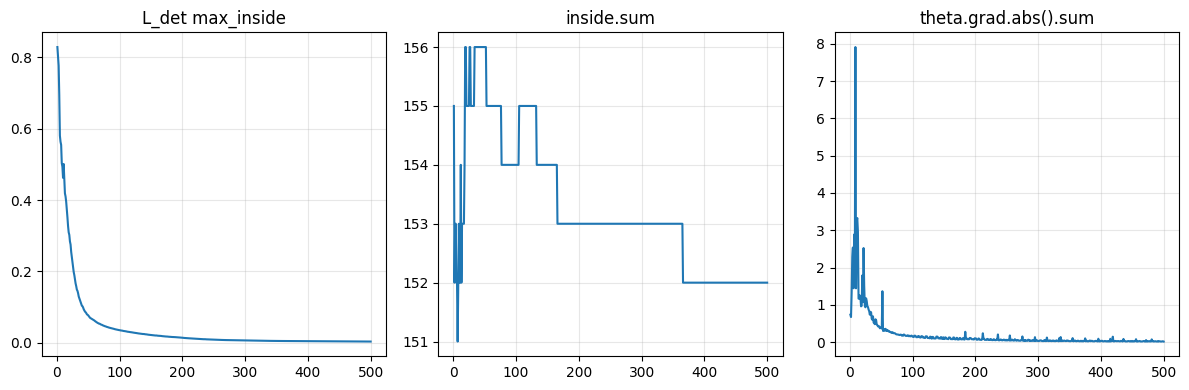

Delta L_det: 0.8248951209243387


In [ ]:
iters = np.array([row[0] for row in history])
l_det = np.array([row[1] for row in history])
inside = np.array([row[4] for row in history])
grad = np.array([row[5] for row in history])

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(iters, l_det)
plt.title('L_det max_inside')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(iters, inside)
plt.title('inside.sum')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(iters, grad)
plt.title('theta.grad.abs().sum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Delta L_det:', l_det[0] - l_det[-1])

## 10. Evaluacion Con YOLO Real Y NMS

Dentro del bbox atacado:
Original: 3 [{'class': 'large vehicle', 'conf': 0.8176000714302063, 'bbox': [451.5555419921875, 332.0740051269531, 488.2384033203125, 386.5482482910156]}, {'class': 'large vehicle', 'conf': 0.804636538028717, 'bbox': [438.6162109375, 332.9168701171875, 474.537353515625, 384.36260986328125]}, {'class': 'large vehicle', 'conf': 0.7863901853561401, 'bbox': [469.1238098144531, 339.4236145019531, 501.2402648925781, 387.6734313964844]}]
Atacado: 0 []
Imagen atacada: /content/drive/MyDrive/Proyecto-VPC/results/digital/adversarial_gradient/adv_result_one_object.jpg
Textura: /content/drive/MyDrive/Proyecto-VPC/results/digital/adversarial_gradient/texture_one_object.png


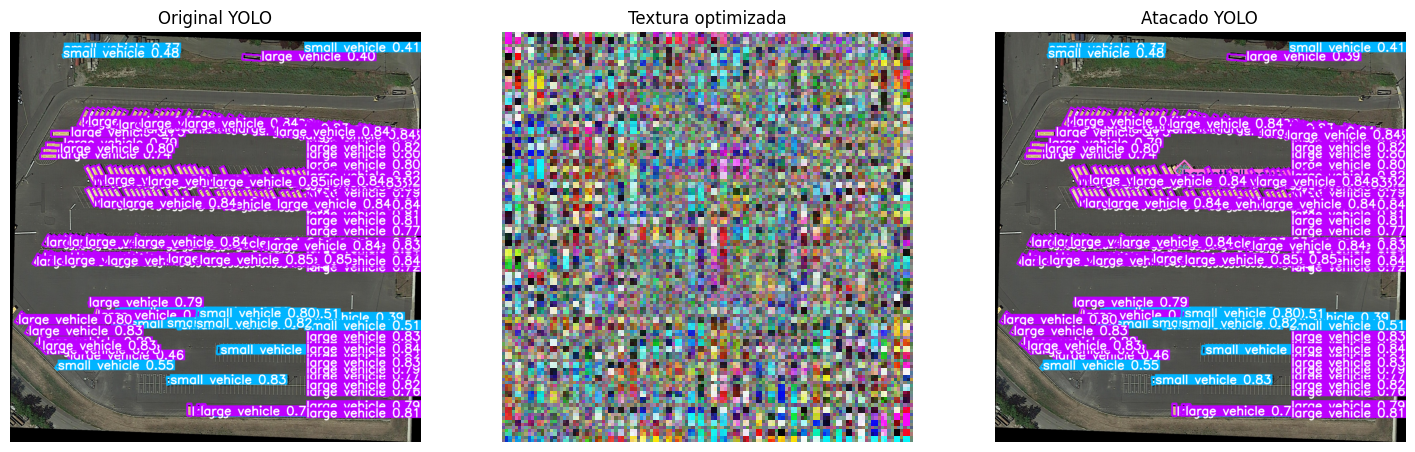

In [ ]:
def count_targets_inside(det, box):
    if det.obb is None:
        return 0, []
    x1, y1, x2, y2 = box
    xyxy = det.obb.xyxy.detach().cpu().numpy()
    cls_ids = det.obb.cls.detach().cpu().numpy().astype(int)
    conf = det.obb.conf.detach().cpu().numpy()
    hits = []
    for bbox, class_id, score in zip(xyxy, cls_ids, conf):
        if class_id not in TARGET_IDS:
            continue
        cx = (bbox[0] + bbox[2]) / 2
        cy = (bbox[1] + bbox[3]) / 2
        if x1 <= cx <= x2 and y1 <= cy <= y2:
            hits.append({'class': CLASS_NAMES[class_id], 'conf': float(score), 'bbox': bbox.tolist()})
    return len(hits), hits


ADV_IMAGE_PATH = OUTPUT_DIR / 'adv_result_one_object.jpg'
TEXTURE_PATH = OUTPUT_DIR / 'texture_one_object.png'

with torch.no_grad():
    final_texture = get_texture()
    adv_image = place_texture(image, final_texture, box, eot=False)

adv_np = (adv_image[0].permute(1, 2, 0).detach().cpu().numpy() * 255).astype(np.uint8)
tex_np = (final_texture.permute(1, 2, 0).detach().cpu().numpy() * 255).astype(np.uint8)
Image.fromarray(adv_np).save(ADV_IMAGE_PATH, quality=95)
Image.fromarray(tex_np).save(TEXTURE_PATH)

det_clean = yolo.predict(str(WORK_IMAGE_PATH), imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
det_adv = yolo.predict(str(ADV_IMAGE_PATH), imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]

clean_inside_count, clean_hits = count_targets_inside(det_clean, box)
adv_inside_count, adv_hits = count_targets_inside(det_adv, box)

print('Dentro del bbox atacado:')
print('Original:', clean_inside_count, clean_hits[:5])
print('Atacado:', adv_inside_count, adv_hits[:5])
print('Imagen atacada:', ADV_IMAGE_PATH)
print('Textura:', TEXTURE_PATH)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(det_clean.plot()[..., ::-1]); ax[0].set_title('Original YOLO'); ax[0].axis('off')
ax[1].imshow(final_texture.detach().permute(1, 2, 0).cpu()); ax[1].set_title('Textura optimizada'); ax[1].axis('off')
ax[2].imshow(det_adv.plot()[..., ::-1]); ax[2].set_title('Atacado YOLO'); ax[2].axis('off')
plt.show()

## 11. Construir Objetos Para Textura Universal

In [ ]:
MAX_UNIVERSAL_OBJECTS = 100
MAX_OBJECTS_PER_IMAGE = 8
MIN_BOX_SIDE = 6
def load_attack_tensor_cpu(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB").resize((size, size))
    arr = np.array(img)
    return torch.from_numpy(arr).float().permute(2, 0, 1).unsqueeze(0) / 255.0
def polygon_to_bbox_scaled(polygon, original_size, size=IMG_SIZE):
    points = np.array(polygon, dtype=np.float32).reshape(-1, 2)
    x1, y1 = points.min(axis=0)
    x2, y2 = points.max(axis=0)
    ow, oh = original_size
    return (
        float(x1 * size / ow),
        float(y1 * size / oh),
        float(x2 * size / ow),
        float(y2 * size / oh),
    )
assert PREDICTIONS_JSON.exists(), f"Falta predictions.json: {PREDICTIONS_JSON}"
payload = json.loads(PREDICTIONS_JSON.read_text(encoding="utf-8"))
image_cache = {}
objetos = []
count_by_image = {}
for record in payload.get("records", []):
    image_path = Path(record["image_path"])
    if not image_path.exists():
        continue
    image_key = image_path.name
    count_by_image.setdefault(image_key, 0)
    with Image.open(image_path) as img_meta:
        original_size = img_meta.size
    if image_path not in image_cache:
        image_cache[image_path] = load_attack_tensor_cpu(image_path)
    # ordenar por confianza para tomar objetos fuertes, pero pocos por imagen
    detections = sorted(
        record.get("detections", []),
        key=lambda d: d.get("confidence", 0),
        reverse=True,
    )
    for det in detections:
        if count_by_image[image_key] >= MAX_OBJECTS_PER_IMAGE:
            break
        if det.get("class_name") not in TARGET_NAMES:
            continue
        polygon = det.get("polygon")
        if polygon is None:
            continue
        box_i = polygon_to_bbox_scaled(polygon, original_size)
        x1, y1, x2, y2 = box_i
        if (x2 - x1) < MIN_BOX_SIDE or (y2 - y1) < MIN_BOX_SIDE:
            continue
        objetos.append((image_cache[image_path], box_i, str(image_path), det.get("class_name")))
        count_by_image[image_key] += 1
        if len(objetos) >= MAX_UNIVERSAL_OBJECTS:
            break
    if len(objetos) >= MAX_UNIVERSAL_OBJECTS:
        break
print("Objetos universales:", len(objetos))
print("Imágenes distintas:", len(count_by_image))
print("Objetos por imagen:")
for image_name, count in count_by_image.items():
    if count > 0:
        print(image_name, count)
assert objetos, "No se construyeron objetos desde predictions.json"

Objetos universales: 64
Imágenes distintas: 10
Objetos por imagen:
P0002.png 8
P0005.png 8
P0008.png 8
P0010.png 8
P0011.png 8
P0012.png 8
P0013.png 8
P0018.png 8


# 11.1 Evaluar Textura En Varios Objetos

In [ ]:
def evaluate_texture_on_object(img_cpu, box_i, image_name, cls_name, texture, idx):
    img_t = img_cpu.to(DEVICE)
    with torch.no_grad():
        adv = place_texture(img_t, texture, box_i, eot=False)
    out_path = OUTPUT_DIR / f"eval_multi_{idx:03d}_{Path(image_name).stem}.jpg"
    adv_np = (adv[0].permute(1, 2, 0).detach().cpu().numpy() * 255).astype(np.uint8)
    Image.fromarray(adv_np).save(out_path, quality=95)
    clean_tmp = OUTPUT_DIR / f"clean_multi_{idx:03d}_{Path(image_name).stem}.jpg"
    clean_np = (img_t[0].permute(1, 2, 0).detach().cpu().numpy() * 255).astype(np.uint8)
    Image.fromarray(clean_np).save(clean_tmp, quality=95)
    det_clean = yolo.predict(str(clean_tmp), imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
    det_adv = yolo.predict(str(out_path), imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
    clean_count, clean_hits = count_targets_inside(det_clean, box_i)
    adv_count, adv_hits = count_targets_inside(det_adv, box_i)
    clean_conf = np.mean([h["conf"] for h in clean_hits]) if clean_hits else 0.0
    adv_conf = np.mean([h["conf"] for h in adv_hits]) if adv_hits else 0.0
    return {
        "idx": idx,
        "image": Path(image_name).name,
        "class": cls_name,
        "clean_count": clean_count,
        "adv_count": adv_count,
        "clean_conf": float(clean_conf),
        "adv_conf": float(adv_conf),
        "confidence_drop": float(clean_conf - adv_conf),
        "success": bool(clean_count > 0 and adv_count < clean_count),
        "clean_path": str(clean_tmp),
        "adv_path": str(out_path),
    }

#11.2 Correr Evaluación Multi-Objeto

In [ ]:
# Usa la textura del ataque de un objeto
final_texture = get_texture().detach()
N_EVAL_OBJECTS = min(20, len(objetos))
eval_results = []
for idx, (img_cpu, box_i, image_name, cls_name) in enumerate(objetos[:N_EVAL_OBJECTS]):
    result = evaluate_texture_on_object(
        img_cpu=img_cpu,
        box_i=box_i,
        image_name=image_name,
        cls_name=cls_name,
        texture=final_texture,
        idx=idx,
    )
    eval_results.append(result)
    print(
        idx,
        result["image"],
        result["class"],
        "clean:", result["clean_count"],
        "adv:", result["adv_count"],
        "drop:", round(result["confidence_drop"], 3),
        "success:", result["success"],
    )

0 P0002.png large vehicle clean: 2 adv: 0 drop: 0.813 success: True
1 P0002.png large vehicle clean: 1 adv: 0 drop: 0.841 success: True
2 P0002.png large vehicle clean: 1 adv: 0 drop: 0.828 success: True
3 P0002.png large vehicle clean: 2 adv: 0 drop: 0.829 success: True
4 P0002.png large vehicle clean: 2 adv: 0 drop: 0.828 success: True
5 P0002.png large vehicle clean: 1 adv: 0 drop: 0.817 success: True
6 P0002.png large vehicle clean: 1 adv: 0 drop: 0.827 success: True
7 P0002.png small vehicle clean: 1 adv: 0 drop: 0.817 success: True
8 P0005.png large vehicle clean: 1 adv: 0 drop: 0.864 success: True
9 P0005.png large vehicle clean: 1 adv: 0 drop: 0.859 success: True
10 P0005.png large vehicle clean: 1 adv: 0 drop: 0.847 success: True
11 P0005.png large vehicle clean: 1 adv: 0 drop: 0.861 success: True
12 P0005.png large vehicle clean: 1 adv: 0 drop: 0.836 success: True
13 P0005.png large vehicle clean: 1 adv: 0 drop: 0.848 success: True
14 P0005.png large vehicle clean: 1 adv: 0 d

# 11.3 Resumen Numérico

In [ ]:
import pandas as pd
df_eval = pd.DataFrame(eval_results)
success_rate = df_eval["success"].mean()
mean_drop = df_eval["confidence_drop"].mean()
print("Objetos evaluados:", len(df_eval))
print("Success rate:", success_rate)
print("Confidence drop promedio:", mean_drop)
df_eval

Objetos evaluados: 20
Success rate: 0.75
Confidence drop promedio: 0.6730153396725654


,idx,image,class,clean_count,adv_count,clean_conf,adv_conf,confidence_drop,success,clean_path,adv_path
0,0,P0002.png,large vehicle,2,0,0.813225,0.000000,0.813225,True,/content/drive/MyDrive/Proyecto-VPC/results/di...,/content/drive/MyDrive/Proyecto-VPC/results/di...
1,1,P0002.png,large vehicle,1,0,0.841476,0.000000,0.841476,True,/content/drive/MyDrive/Proyecto-VPC/results/di...,/content/drive/MyDrive/Proyecto-VPC/results/di...
2,2,P0002.png,large vehicle,1,0,0.827917,0.000000,0.827917,True,/content/drive/MyDrive/Proyecto-VPC/results/di...,/content/drive/MyDrive/Proyecto-VPC/results/di...
3,3,P0002.png,large vehicle,2,0,0.829382,0.000000,0.829382,True,/content/drive/MyDrive/Proyecto-VPC/results/di...,/content/drive/MyDrive/Proyecto-VPC/results/di...
4,4,P0002.png,large vehicle,2,0,0.827503,0.000000,0.827503,True,/content/drive/MyDrive/Proyecto-VPC/results/di...,/content/drive/MyDrive/Proyecto-VPC/results/di...
5,5,P0002.png,large vehicle,1,0,0.817063,0.000000,0.817063,True,/content/drive/MyDrive/Proyecto-VPC/results/di...,/content/drive/MyDrive/Proyecto-VPC/results/di...
6,6,P0002.png,large vehicle,1,0,0.826918,0.000000,0.826918,True,/content/drive/MyDrive/Proyecto-VPC/results/di...,/content/drive/MyDrive/Proyecto-VPC/results/di...
7,7,P0002.png,small vehicle,1,0,0.816672,0.000000,0.816672,True,/content/drive/MyDrive/Proyecto-VPC/results/di...,/content/drive/MyDrive/Proyecto-VPC/results/di...
8,8,P0005.png,large vehicle,1,0,0.863889,0.000000,0.863889,True,/content/drive/MyDrive/Proyecto-VPC/results/di...,/content/drive/MyDrive/Proyecto-VPC/results/di...
9,9,P0005.png,large vehicle,1,0,0.859158,0.000000,0.859158,True,/content/drive/MyDrive/Proyecto-VPC/results/di...,/content/drive/MyDrive/Proyecto-VPC/results/di...


# 11.4 Guardar Resultados

In [ ]:
multi_eval_csv = OUTPUT_DIR / "one_texture_multi_object_eval.csv"
multi_eval_json = OUTPUT_DIR / "one_texture_multi_object_eval.json"
df_eval.to_csv(multi_eval_csv, index=False)
with multi_eval_json.open("w", encoding="utf-8") as f:
    json.dump(eval_results, f, indent=2)
print("Guardado:")
print(multi_eval_csv)
print(multi_eval_json)

Guardado:
/content/drive/MyDrive/Proyecto-VPC/results/digital/adversarial_gradient/one_texture_multi_object_eval.csv
/content/drive/MyDrive/Proyecto-VPC/results/digital/adversarial_gradient/one_texture_multi_object_eval.json


# 11.5 Visualizar Casos Exitosos Y Fallidos

Exitosos: 15
Fallidos: 5


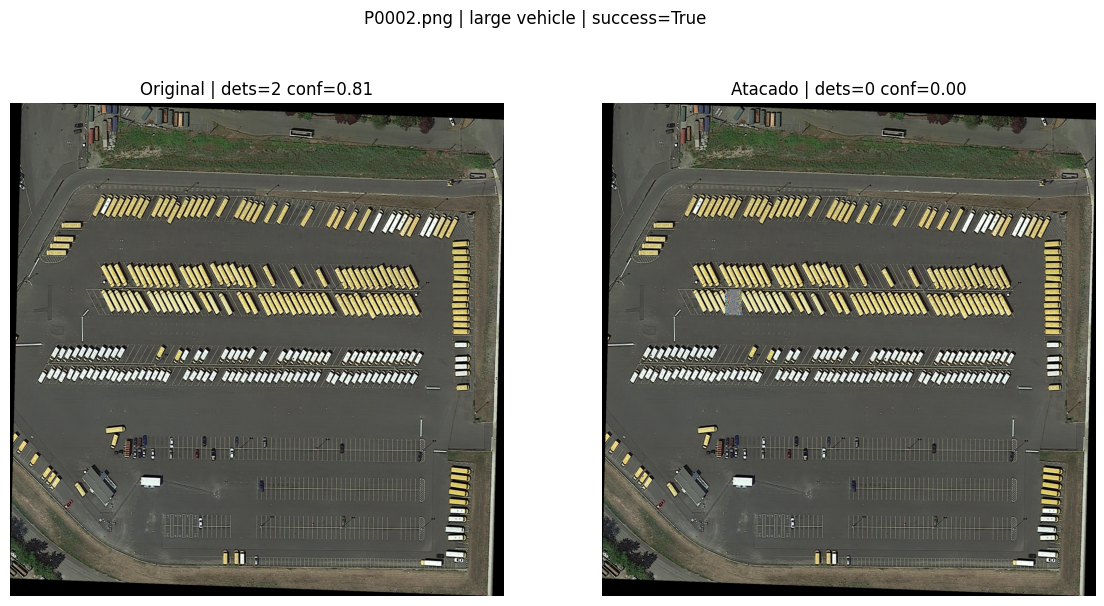

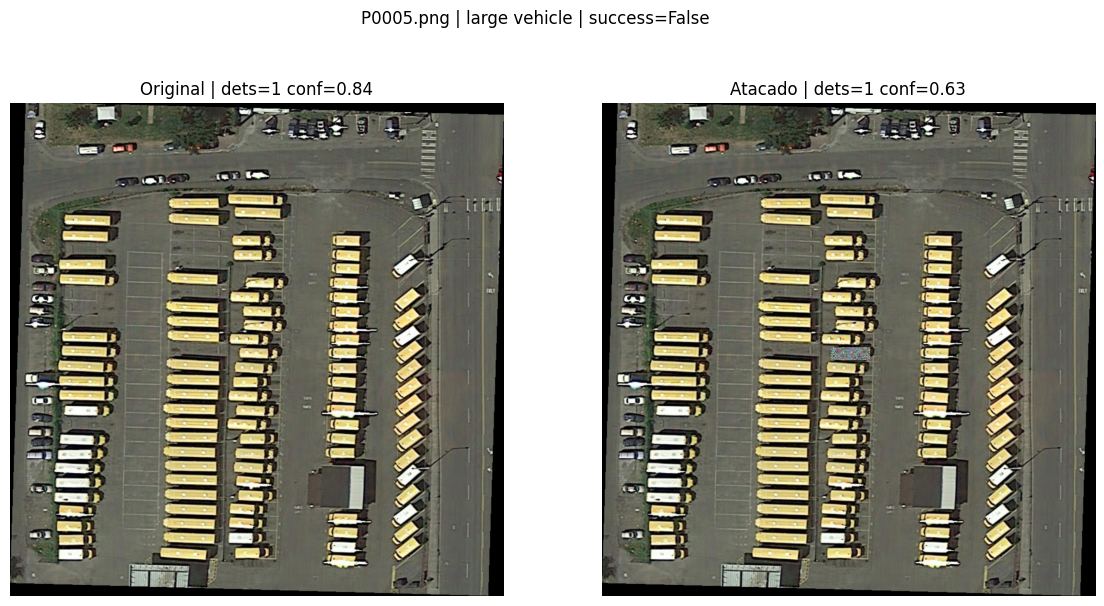

In [ ]:
success_cases = df_eval[df_eval["success"] == True]
fail_cases = df_eval[df_eval["success"] == False]
print("Exitosos:", len(success_cases))
print("Fallidos:", len(fail_cases))
def show_eval_case(row):
    clean_img = Image.open(row["clean_path"]).convert("RGB")
    adv_img = Image.open(row["adv_path"]).convert("RGB")
    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(clean_img)
    plt.title(f"Original | dets={row['clean_count']} conf={row['clean_conf']:.2f}")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(adv_img)
    plt.title(f"Atacado | dets={row['adv_count']} conf={row['adv_conf']:.2f}")
    plt.axis("off")
    plt.suptitle(f"{row['image']} | {row['class']} | success={row['success']}")
    plt.show()
if len(success_cases):
    show_eval_case(success_cases.iloc[0])
if len(fail_cases):
    show_eval_case(fail_cases.iloc[0])

## 12. Loop Universal

Usa una sola textura sobre multiples objetos. Primero puedes dejar `USE_EOT_UNIV=False`; cuando funcione, cambia a `True`.

In [ ]:
UNIVERSAL_ITERS = 800
UNIVERSAL_LR = 0.03
USE_EOT_UNIV = False
LAMBDA_TV_UNIV = 0.0

theta_univ = theta.detach().clone().requires_grad_(True)
optimizer_univ = torch.optim.Adam([theta_univ], lr=UNIVERSAL_LR)

def get_texture_universal():
    return torch.sigmoid(theta_univ)

history_univ = []

for it in range(1, UNIVERSAL_ITERS + 1):
    img_cpu, box_i, image_name, cls_name = random.choice(objetos)
    img_t = img_cpu.to(DEVICE)
    optimizer_univ.zero_grad(set_to_none=True)

    texture = get_texture_universal()
    adv = place_texture(img_t, texture, box_i, eot=USE_EOT_UNIV)
    raw_adv = yolo_forward_raw(adv)
    l_det, dbg = detection_loss(raw_adv, box_i, return_debug=True)
    l_tv = tv_loss(texture)
    loss = l_det + LAMBDA_TV_UNIV * l_tv
    loss.backward()
    grad_sum = float(theta_univ.grad.abs().sum().detach().cpu()) if theta_univ.grad is not None else 0.0
    optimizer_univ.step()

    history_univ.append((it, l_det.item(), l_tv.item(), loss.item(), dbg['inside_sum'], grad_sum, image_name, cls_name))
    if it == 1 or it % 100 == 0:
        print(f"it {it:4d} | L_det {l_det.item():.4f} | inside {dbg['inside_sum']:.0f} | grad {grad_sum:.2e} | {Path(image_name).name} {cls_name}")

    if dbg['inside_sum'] <= 0 or grad_sum <= 0:
        raise RuntimeError('Loop universal sin inside o sin gradiente')

theta = theta_univ
optimizer = optimizer_univ
print('Loop universal terminado')
print('L_det inicio:', history_univ[0][1], '| L_det final:', history_univ[-1][1])

it    1 | L_det 0.4270 | inside 52 | grad 4.02e+00 | P0013.png small vehicle
it  100 | L_det 0.7607 | inside 219 | grad 1.74e+00 | P0008.png large vehicle
it  200 | L_det 0.8433 | inside 48 | grad 1.24e-01 | P0018.png small vehicle
it  300 | L_det 0.0013 | inside 112 | grad 1.08e-01 | P0005.png large vehicle
it  400 | L_det 0.1455 | inside 53 | grad 1.88e+00 | P0013.png small vehicle
it  500 | L_det 0.0021 | inside 164 | grad 2.32e-01 | P0005.png large vehicle
it  600 | L_det 0.0178 | inside 278 | grad 5.32e-01 | P0005.png large vehicle
it  700 | L_det 0.7883 | inside 22 | grad 1.60e-01 | P0018.png small vehicle
it  800 | L_det 0.0001 | inside 128 | grad 9.49e-03 | P0002.png large vehicle
Loop universal terminado
L_det inicio: 0.4270024299621582 | L_det final: 0.00013550811854656786


## 13. Exportar Textura

In [ ]:
export_path = OUTPUT_DIR / 'textura_adversarial_universal.png'
texture_np = (get_texture().detach().permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
Image.fromarray(texture_np).resize((1024, 1024), Image.NEAREST).save(export_path)
print('Guardada:', export_path)

Guardada: /content/drive/MyDrive/Proyecto-VPC/results/digital/adversarial_gradient/textura_adversarial_universal.png
